In [1]:
from importlib import reload
from IPython.core.interactiveshell import InteractiveShell
%load_ext autoreload
InteractiveShell.ast_node_interactivity = "all"
import logging
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [2]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

2025-01-21 13:52:08,873 - numexpr.utils - INFO - Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
2025-01-21 13:52:08,875 - numexpr.utils - INFO - NumExpr defaulting to 8 threads.
/cmnfs/home/z.xiao/miniconda3/envs/sbs/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Result on HYE transfer to H

## MaxQuant as a reference

In [3]:
maxquant_search_evidence = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/HeLa_sample_amount_and_LC_columns/30min_5ug_ref/txt_30min_5ug_HYE_search/evidence.txt",
    sep="\t",
)
maxquant_search_evidence["Raw file"].unique()
maxquant_search_evidence = maxquant_search_evidence.loc[
    maxquant_search_evidence["Raw file"] == "Hela_30min_5ug_R2_RA1_1_5163"
]
maxquant_search_evidece = maxquant_search_evidence.loc[
    maxquant_search_evidence["Reverse"] != "+"
]
maxquant_search_evidence["Taxonomy names"].value_counts()

/tmp/ipykernel_2130157/1522844572.py:1: DtypeWarning: Columns (61,69) have mixed types. Specify dtype option on import or set low_memory=False.
  maxquant_search_evidence = pd.read_csv(


array(['Hela_30min_5ug_R2_RA1_1_5163', 'Hela_30min_5ug_R3_RA1_1_5164',
       'Hela_30min_5ug_R1_RA1_1_5162'], dtype=object)

Taxonomy names
Homo sapiens                                                   48353
Saccharomyces cerevisiae;Homo sapiens                           2559
Saccharomyces cerevisiae                                         708
Saccharomyces cerevisiae;Homo sapiens;Escherichia coli K-12      106
Homo sapiens;Escherichia coli K-12                                73
Escherichia coli K-12                                              8
Name: count, dtype: int64

In [4]:
maxquant_search_evidence["Taxonomy names"].str.contains("Homo sapiens").sum()
(1 - maxquant_search_evidence["Taxonomy names"].str.contains("Homo sapiens")).sum()

51091

716

In [5]:
# Calculate ratio (Y+E)/H
716 / 51091

0.014014209939128223

## SWAPS

In [6]:
# Load total
result_path = "/cmnfs/proj/ORIGINS/SWAPS_exp/short_gradient/30min_3to45_7R_30min_HYE_lib_im_ref_rt_lowess_20250113_141405_841999"
maxquant_dict = pd.read_pickle(os.path.join(result_path, "maxquant_result_ref.pkl"))
ps_act = pd.read_csv(
    os.path.join(
        result_path,
        "peak_selection",
        "exp_20250113_142025_985371",
        "pept_act_sum_ps_full_tdc_fdr_thres.csv",
    )
)
ps_act_full_df = pd.merge(
    left=ps_act, right=maxquant_dict, on=["mz_rank", "Decoy"], how="left"
)
maxquant_dict["Taxonomy names"].value_counts()

Taxonomy names
Saccharomyces cerevisiae                          24413
Escherichia coli K-12                             19126
Homo sapiens                                      17508
Saccharomyces cerevisiae;Homo sapiens               372
Homo sapiens;Escherichia coli K-12                  134
Saccharomyces cerevisiae;Escherichia coli K-12       60
Name: count, dtype: int64

In [7]:
eval_acc = pd.merge(
    left=ps_act,
    right=maxquant_dict,
    on=["mz_rank", "Decoy"],
    how="right",
    indicator="id_indicator",
)
eval_acc["identified"] = True
eval_acc.loc[eval_acc["id_indicator"] == "right_only", "identified"] = False

In [8]:
eval_acc_no_decoy = eval_acc.loc[~eval_acc["Decoy"]]

In [9]:
eval_acc_no_decoy.loc[
    eval_acc_no_decoy["Taxonomy names"].str.contains("Homo sapiens", na=False), "P_or_N"
] = "P"
eval_acc_no_decoy.loc[
    ~eval_acc_no_decoy["Taxonomy names"].str.contains("Homo sapiens", na=False),
    "P_or_N",
] = "N"
eval_acc_no_decoy.loc[eval_acc_no_decoy["Taxonomy names"].isna(), "P_or_N"] = "P"

/tmp/ipykernel_2130157/1815183582.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval_acc_no_decoy.loc[


In [10]:
tp = eval_acc_no_decoy.loc[
    eval_acc_no_decoy["identified"] & (eval_acc_no_decoy["P_or_N"] == "P")
].shape[0]
tn = eval_acc_no_decoy.loc[
    (~eval_acc_no_decoy["identified"]) & (eval_acc_no_decoy["P_or_N"] == "N")
].shape[0]
fp = eval_acc_no_decoy.loc[
    (~eval_acc_no_decoy["identified"]) & (eval_acc_no_decoy["P_or_N"] == "P")
].shape[0]
fn = eval_acc_no_decoy.loc[
    eval_acc_no_decoy["identified"] & (eval_acc_no_decoy["P_or_N"] == "N")
].shape[0]
(tp + tn + fp + fn)
(tp + tn) / (tp + tn + fp + fn)

82623

0.909335173014778

In [11]:
# reported total FDR
ps_act_full_df["Decoy"].sum() / (1 - ps_act_full_df["Decoy"]).sum()

0.0345360275577968

/cmnfs/home/z.xiao/miniconda3/envs/sbs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


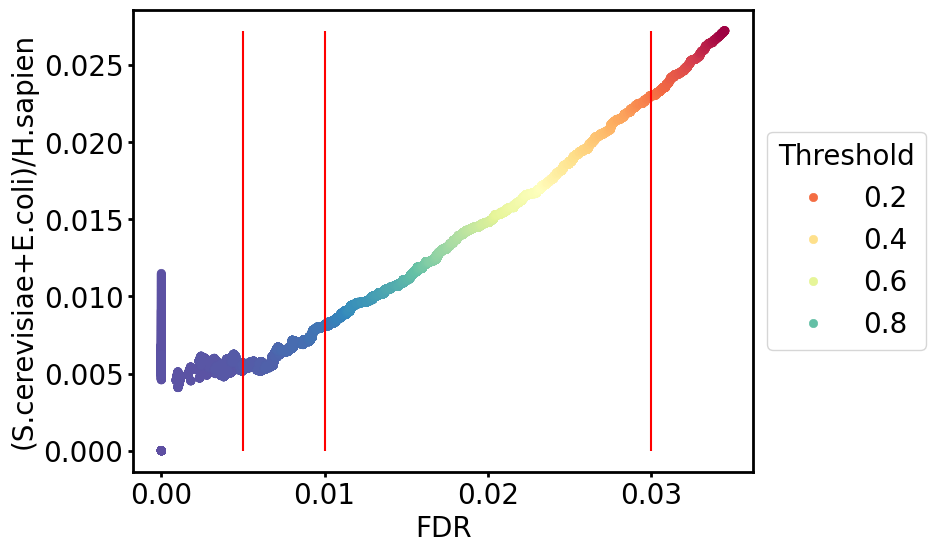

In [12]:
# Calibration curve
from peak_detection_2d.utils import plot_fdr_and_id

score_col = "target_decoy_score"
filter_dict = None
return_plot = True
save_dir = None
dataset_name = ""
pred_df_new = ps_act_full_df.copy()
if score_col not in ps_act_full_df.columns:
    if score_col == "log_sum_intensity":
        pred_df_new["log_sum_intensity"] = np.log10(pred_df_new["sum_intensity"] + 1)
    else:
        raise ValueError(f"score_col {score_col} not in pred_df")
if filter_dict is not None:
    pred_df_new = _filter_pred(filter_dict, pred_df_new)

pred_df_new = pred_df_new.sort_values(score_col, ascending=False)
pred_df_new["Target"] = pred_df_new["Decoy"] == 0
pred_df_new["fdr"] = (pred_df_new["Decoy"].cumsum()) / np.maximum(
    pred_df_new["Target"].cumsum(), 1
)
pred_df_new["Human"] = (~pred_df_new["Decoy"]) & (
    pred_df_new["Taxonomy names"].isna()
    | pred_df_new["Taxonomy names"].str.contains("Homo sapiens")
)
pred_df_new["NotHuman"] = (~pred_df_new["Human"]) & (~pred_df_new["Decoy"])
pred_df_new["(S.cerevisiae+E.coli)/H.sapien"] = (
    pred_df_new["NotHuman"].cumsum() / pred_df_new["Human"].cumsum()
)
pred_df_new["N_identified_target"] = pred_df_new["Target"].cumsum()
if return_plot:
    plot_fdr_and_id(
        pred_df_new,
        filter_dict,
        save_dir,
        dataset_name,
        y_col="(S.cerevisiae+E.coli)/H.sapien",
        mark_x=[0.005, 0.01, 0.03],
        title=None,
    )

In [36]:
# Calculating (Y+E)/H ratio
ps_act_full_df.loc[~ps_act_full_df["Decoy"], "Taxonomy names"].value_counts()
# Hela reference doesn't not have Taxonomy names entry
ps_act_full_df.loc[~ps_act_full_df["Decoy"], "Taxonomy names"].isna().sum()
ps_act_full_df.loc[~ps_act_full_df["Decoy"], "Taxonomy names"].str.contains(
    "Homo sapiens"
).sum()
(
    1
    - ps_act_full_df.loc[~ps_act_full_df["Decoy"], "Taxonomy names"].str.contains(
        "Homo sapiens"
    )
).sum()
1493 / (6987 + 47838)

Taxonomy names
Homo sapiens                             6888
Saccharomyces cerevisiae                  906
Escherichia coli K-12                     587
Saccharomyces cerevisiae;Homo sapiens      91
Homo sapiens;Escherichia coli K-12          8
Name: count, dtype: int64

47838

6987

1493

In [42]:
total_human = 24413 + 372 + 134 + 103632
total_y_e = 19126 + 17508 + 50

# Result on HYE ratio

In [6]:
import seaborn as sns


color_dict = {
    "Homo sapiens": "#1f77b4",  # blue
    "Saccharomyces cerevisiae": "#2ca02c",  # green
    "Escherichia coli K-12": "#ff7f0e",  # orange
}

In [7]:
def filter_and_merge(
    df, tax_names=["Homo sapiens", "Saccharomyces cerevisiae", "Escherichia coli K-12"]
):
    logging.info("Before processing %s", df.shape)
    df = df.loc[~df["Decoy"], :]
    logging.info("After removing decoy %s", df.shape)
    df = df.loc[df["Taxonomy names"].isin(tax_names), :]
    logging.info("After removing shared-precursors %s", df.shape)
    return df

## MaxQuant four replicates ion

In [14]:
mixture_maxquant = pd.read_csv(
    "/cmnfs/proj/ORIGINS/data/species_mix/library/txt_HYE_30min_mixture/evidence.txt",
    sep="\t",
)
mixture_maxquant = mixture_maxquant.loc[
    mixture_maxquant["Taxonomy names"].isin(
        [
            "Escherichia coli K-12",
            "Saccharomyces cerevisiae",
            "Homo sapiens",
        ]
    )
]
mixture_maxquant = (
    mixture_maxquant.groupby(
        ["Experiment", "Modified sequence", "Charge", "Taxonomy names"]
    )
    .agg({"Intensity": ["median", "count"]})
    .reset_index()
)
mixture_maxquant.columns = [
    "Experiment",
    "Modified sequence",
    "Charge",
    "Taxonomy names",
    "Intensity",
    "count",
]
mixture_maxquant = mixture_maxquant.loc[mixture_maxquant["count"] >= 3]
mixture_maxquant_A = mixture_maxquant.loc[mixture_maxquant["Experiment"] == "A"]
mixture_maxquant_B = mixture_maxquant.loc[mixture_maxquant["Experiment"] == "B"]
mixture_maxquant_fc = pd.merge(
    left=mixture_maxquant_A,
    right=mixture_maxquant_B,
    on=["Modified sequence", "Charge", "Taxonomy names"],
    suffixes=["_1", "_2"],
)
mixture_maxquant_fc["fold_change"] = (
    mixture_maxquant_fc["Intensity_1"] / mixture_maxquant_fc["Intensity_2"]
)
mixture_maxquant_fc["fold_change"] = np.log2(mixture_maxquant_fc["fold_change"])
mixture_maxquant_fc["mean_intensity"] = np.log2(
    np.mean(mixture_maxquant_fc[["Intensity_1", "Intensity_2"]], axis=1)
)

/tmp/ipykernel_2129029/3210239657.py:1: DtypeWarning: Columns (62,70) have mixed types. Specify dtype option on import or set low_memory=False.
  mixture_maxquant = pd.read_csv(


/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3

<Axes: xlabel='mean_intensity', ylabel='fold_change'>

fold_change                    
                               count    median       std
Taxonomy names                                          
Escherichia coli K-12           2250 -1.893267  0.405173
Homo sapiens                   20622 -0.045589  0.263343
Saccharomyces cerevisiae        7612  0.900693  0.402060

(-6.0, 6.0)

(14.0, 30.0)

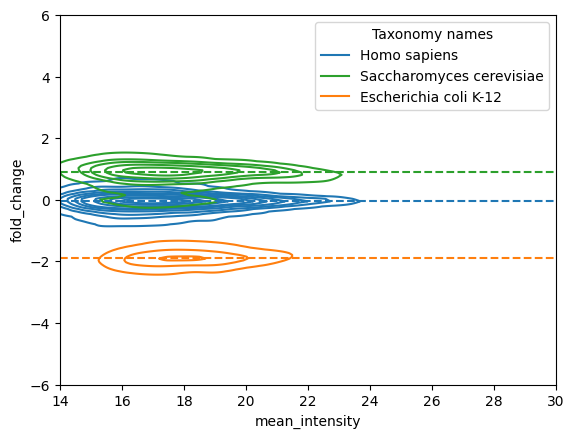

In [81]:
# KDE plot MaxQuant
sns.kdeplot(
    data=mixture_maxquant_fc,
    y="fold_change",
    x="mean_intensity",
    hue="Taxonomy names",
    palette=color_dict,
)
median_fold_change = mixture_maxquant_fc.groupby("Taxonomy names")[
    "fold_change"
].median()
for i, (tax_name, median_val) in enumerate(median_fold_change.items()):
    plt.axhline(
        median_val,
        linestyle="--",
        label=f"{tax_name} median",
        color=color_dict[tax_name],
    )
# plt.legend(loc="upper right")
mixture_maxquant_fc.groupby("Taxonomy names").agg(
    {"fold_change": ["count", "median", "std"]}
)
plt.ylim((-6, 6))
plt.xlim((14, 30))

## SWAPS for replicates ion

In [3]:
import glob

pattern = "30min_HYE_30min_HYE_library_im_ref_*_*_rt_lowess_*_*_*"

matching_files = glob.glob(pattern, root_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/")
matching_files = [
    os.path.join("/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/", f) for f in matching_files
]
matching_files

['/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_A_5137_rt_lowess_20250115_171455_760888',
 '/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_A_5139_rt_lowess_20250115_171521_659609',
 '/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_B_5134_rt_lowess_20250114_110816_258321',
 '/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_A_5133_rt_lowess_20250113_155209_323140',
 '/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_B_5136_rt_lowess_20250115_092421_512655',
 '/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_A_5135_rt_lowess_20250115_105013_103329',
 '/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_B_5138_rt_lowess_20250115_171456_495843',
 '/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_HYE_30min_HYE_library_im_ref_B_5140_rt_lowess_20250115_171544_923278']

In [43]:
%autoreload
from postprocessing.protein_quant import prepare_input_for_triqler
out_dir, evidence_all = prepare_input_for_triqler(
    matching_files,
    out_dir="/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_mixture_libaray/",
    ps_exp_folder="auto",
    # extra_col_to_keep=['Taxonomy names'],
    remove_shared_peptides=True,
    remove_shared_proteins=True,
    filter_species=[
        "Escherichia coli K-12",
        "Saccharomyces cerevisiae",
        "Homo sapiens",
    ],
    extra_col_to_keep=["Taxonomy names", "Decoy"]
)

2025-01-16 10:27:57,991 - postprocessing.protein_quant - INFO - Processing A_5137
2025-01-16 10:27:59,901 - postprocessing.protein_quant - INFO - Removing missing taxonomy names
2025-01-16 10:28:00,003 - postprocessing.protein_quant - INFO - Removing shared proteins (across species), before removal: 146389
2025-01-16 10:28:00,116 - postprocessing.protein_quant - INFO - Removed shared proteins (across species), after removal: 144707
2025-01-16 10:28:00,117 - postprocessing.protein_quant - INFO - Filtering species: ['Escherichia coli K-12', 'Saccharomyces cerevisiae', 'Homo sapiens'], before filtering: 144707
2025-01-16 10:28:00,367 - postprocessing.protein_quant - INFO - Filtering species: ['Escherichia coli K-12', 'Saccharomyces cerevisiae', 'Homo sapiens'], after filtering: 144707
2025-01-16 10:28:00,368 - postprocessing.protein_quant - INFO - Removing shared peptides, before removal: 144707
2025-01-16 10:28:00,453 - postprocessing.protein_quant - INFO - Removed shared peptides, after

In [47]:
# Total FDR
6609 / 547262

0.012076482562282782

In [3]:
evidence_all = pd.read_csv(
    "/cmnfs/proj/ORIGINS/SWAPS_exp/mixture/30min_mixture_libaray/swaps_input_triqler_EscherichiacoliK-12_Saccharomycescerevisiae_Homosapiens.tsv",
    sep="\t",
)
evidence_all = evidence_all.loc[~evidence_all["Decoy"]]
evidence_all_group = (
    evidence_all.groupby(["condition", "charge", "peptide", "Taxonomy names"])
    .agg({"intensity": ["median", "count"]})
    .reset_index()
)
evidence_all_group.columns = [
    "condition",
    "charge",
    "peptide",
    "Taxonomy names",
    "intensity",
    "count",
]
evidence_all_group = evidence_all_group.loc[evidence_all_group["count"] >= 3]
evidence_all_group_1 = evidence_all_group.loc[evidence_all_group["condition"] == 1]
evidence_all_group_2 = evidence_all_group.loc[evidence_all_group["condition"] == 2]
evidence_all_group_fc = pd.merge(
    left=evidence_all_group_1,
    right=evidence_all_group_2,
    on=["charge", "peptide", "Taxonomy names"],
    suffixes=["_1", "_2"],
)
evidence_all_group_fc["fold_change"] = (
    evidence_all_group_fc["intensity_1"] / evidence_all_group_fc["intensity_2"]
)
evidence_all_group_fc["fold_change"] = np.log2(evidence_all_group_fc["fold_change"])
evidence_all_group_fc["mean_intensity"] = np.log2(
    np.mean(evidence_all_group_fc[["intensity_1", "intensity_2"]], axis=1)
)

<Figure size 800x600 with 0 Axes>

/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3

(-6.0, 6.0)

(14.0, 30.0)

Text(0.5, 0, 'Mean SWAPS Inferred Intensity (Log2)')

Text(0, 0.5, 'Fold Change (Log2)')

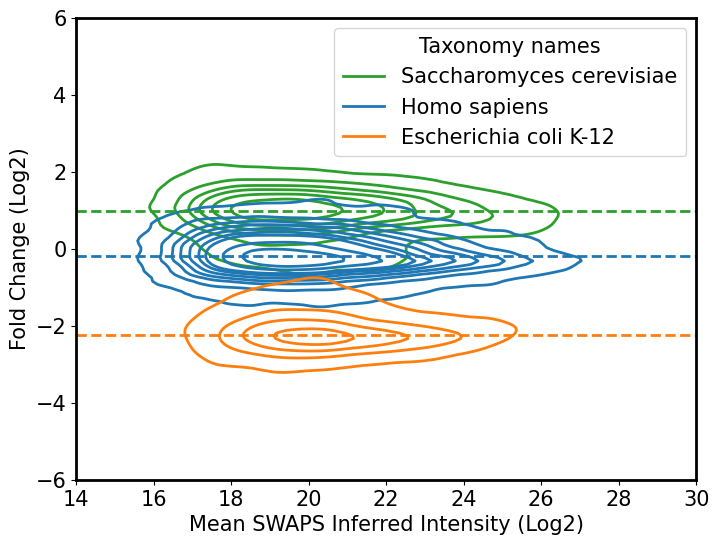

In [46]:
# KDE plot for all SWAPS results
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.rcParams.update({"font.size": 15, "lines.linewidth": 2})
ax = sns.kdeplot(
    data=evidence_all_group_fc,
    y="fold_change",
    x="mean_intensity",
    hue="Taxonomy names",
    palette=color_dict,
    fontsize=15,
)
for spine in ax.spines.values():
    spine.set_linewidth(2)  # Increase this value for thicker lines
    # Optional: you can also make tick marks thicker
median_fold_change = evidence_all_group_fc.groupby("Taxonomy names")[
    "fold_change"
].median()
for i, (tax_name, median_val) in enumerate(median_fold_change.items()):
    plt.axhline(
        median_val,
        linestyle="--",
        label=f"{tax_name} median",
        color=color_dict[tax_name],
    )

plt.ylim((-6, 6))
plt.xlim((14, 30))
plt.xlabel("Mean SWAPS Inferred Intensity (Log2)")
plt.ylabel("Fold Change (Log2)")

In [12]:
evidence_all_group_fc.groupby("Taxonomy names").agg(
    {"fold_change": ["count", "median", "std"], "mean_intensity": ["median"]}
)

fold_change                     mean_intensity
                               count    median       std         median
Taxonomy names                                                         
Escherichia coli K-12           7403 -2.238164  0.701891      20.265320
Homo sapiens                   40278 -0.194269  0.493765      19.763021
Saccharomyces cerevisiae       17856  0.988882  0.595261      19.847799

In [15]:
mq_swaps_evidence = pd.merge(
    mixture_maxquant_fc,
    evidence_all_group_fc,
    left_on=["Modified sequence", "Charge", "Taxonomy names"],
    right_on=["peptide", "charge", "Taxonomy names"],
    suffixes=["_mq", "_swaps"],
    how="outer",
    indicator=True,
)

/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


KeyboardInterrupt: 

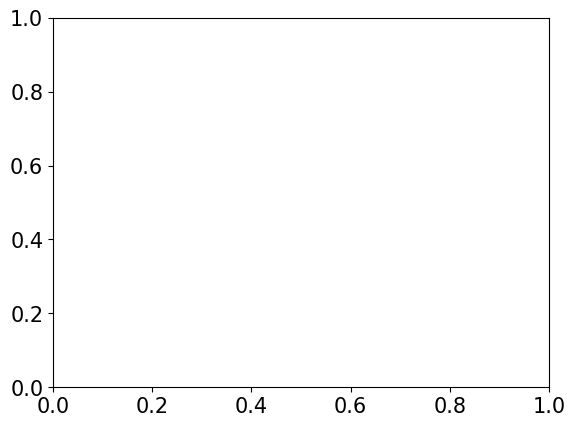

In [16]:
sns.kdeplot(
    data=mq_swaps_evidence.loc[mq_swaps_evidence["_merge"] != "right_only"],
    y="fold_change_mq",
    x="mean_intensity_mq",
    # alpha=0.5,
    # s=8,
    hue="Taxonomy names",
    palette=color_dict,
)
plt.ylim((-6, 6))
plt.xlim((14, 30))
plt.title("MaxQuant")

In [18]:
mq_swaps_evidence.loc[mq_swaps_evidence["_merge"] != "right_only"].groupby(
    "Taxonomy names"
).agg({"fold_change_mq": ["count", "median", "std"], "mean_intensity_mq": ["median"]})

fold_change_mq                     mean_intensity_mq
                                  count    median       std            median
Taxonomy names                                                               
Escherichia coli K-12              2250 -1.893267  0.405173         18.037495
Homo sapiens                      20622 -0.045589  0.263343         17.101724
Saccharomyces cerevisiae           7612  0.900693  0.402060         17.488209

In [ ]:
sns.kdeplot(
    data=mq_swaps_evidence.loc[mq_swaps_evidence["_merge"] == "right_only"],
    y="fold_change_swaps",
    x="mean_intensity_swaps",
    # alpha=0.5,
    # s=8,
    hue="Taxonomy names",
    palette=color_dict,
)

plt.ylim((-6, 6))
plt.xlim((14, 30))
plt.title("SWAPS only")

NameError: name 'mq_swaps_evidence' is not defined

In [19]:
mq_swaps_evidence.loc[mq_swaps_evidence["_merge"] == "right_only"].groupby(
    "Taxonomy names"
).agg(
    {
        "fold_change_swaps": ["count", "median", "std"],
        "mean_intensity_swaps": ["median"],
    }
)

fold_change_swaps                      \
                                     count    median       std   
Taxonomy names                                                   
Escherichia coli K-12                 5178 -2.195610  0.797914   
Homo sapiens                         20012 -0.177793  0.569461   
Saccharomyces cerevisiae             10404  0.964862  0.665531   

                         mean_intensity_swaps  
                                       median  
Taxonomy names                                 
Escherichia coli K-12               19.717130  
Homo sapiens                        19.103495  
Saccharomyces cerevisiae            19.117783

/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3

<Axes: xlabel='mean_intensity_swaps', ylabel='fold_change_swaps'>

fold_change_swaps                    
                                     count    median       std
Taxonomy names                                                
Escherichia coli K-12                 2225 -2.297256  0.382039
Homo sapiens                         20266 -0.208529  0.405374
Saccharomyces cerevisiae              7452  1.021606  0.478571

(-6.0, 6.0)

(14.0, 30.0)

Text(0.5, 1.0, 'Both')

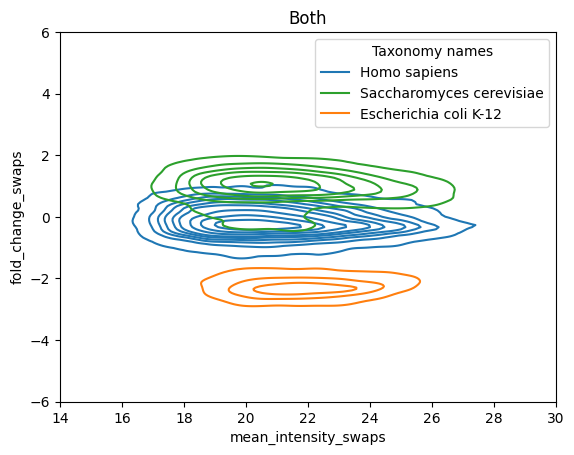

In [87]:
sns.kdeplot(
    data=mq_swaps_evidence.loc[mq_swaps_evidence["_merge"] == "both"],
    y="fold_change_swaps",
    x="mean_intensity_swaps",
    # alpha=0.5,
    # s=8,
    hue="Taxonomy names",
    palette=color_dict,
)

plt.ylim((-6, 6))
plt.xlim((14, 30))
plt.title("Both")

In [21]:
mq_swaps_evidence.loc[mq_swaps_evidence["_merge"] == "both"].groupby(
    "Taxonomy names"
).agg(
    {
        "fold_change_swaps": ["count", "median", "std"],
        "mean_intensity_swaps": ["median"],
    }
)

fold_change_swaps                      \
                                     count    median       std   
Taxonomy names                                                   
Escherichia coli K-12                 2225 -2.297256  0.382039   
Homo sapiens                         20266 -0.208529  0.405374   
Saccharomyces cerevisiae              7452  1.021606  0.478571   

                         mean_intensity_swaps  
                                       median  
Taxonomy names                                 
Escherichia coli K-12               21.791285  
Homo sapiens                        20.513737  
Saccharomyces cerevisiae            21.031646

/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/cmnfs/home/z.xiao/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='fold_change', ylabel='Density'>

fold_change                    
                               count    median       std
Taxonomy names                                          
Escherichia coli K-12           7403 -2.238164  0.701891
Homo sapiens                   40278 -0.194269  0.493765
Saccharomyces cerevisiae       17856  0.988882  0.595261

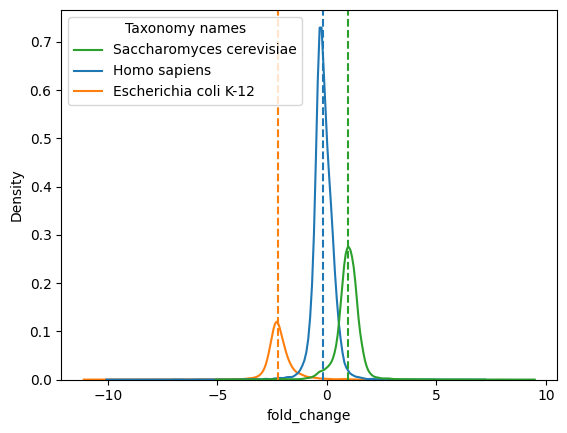

In [58]:
import seaborn as sns


color_dict = {
    "Homo sapiens": "#1f77b4",  # blue
    "Saccharomyces cerevisiae": "#2ca02c",  # greenevidence_all_group_fc
    "Escherichia coli K-12": "#ff7f0e",  # orange
}

sns.kdeplot(
    data=evidence_all_group_fc,
    x="fold_change",
    hue="Taxonomy names",
    palette=color_dict,
)
median_fold_change = evidence_all_group_fc.groupby("Taxonomy names")[
    "fold_change"
].median()
for i, (tax_name, median_val) in enumerate(median_fold_change.items()):
    plt.axvline(
        median_val,
        linestyle="--",
        label=f"{tax_name} median",
        color=color_dict[tax_name],
    )
evidence_all_group_fc.groupby("Taxonomy names").agg(
    {"fold_change": ["count", "median", "std"]}
)